In [1]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import pydeseq2 as dseq2
import seaborn as sns
import numpy as np
import os

In [2]:
import re

s = '4-6,1-3,7'

idx = []

for e in s.split(','):
    if re.fullmatch(r"(\d+)-(\d+)", e):
        a, b = e.split('-')
        idx.extend([x for x in range(int(a), int(b)+1)])
    else:
        idx.append(int(e))

idx

[4, 5, 6, 1, 2, 3, 7]

In [3]:
os.chdir('/home/pablosm/Escritorio/LCG/2026-1/biopython')
count = pd.read_csv('data/count_matrix.tsv', sep='\t', index_col=0); count.index.name = None; display(count)

# Reorder dataframe
x = list(range(4,7)) + list(range(1,4)) + [7]
count = count.iloc[:, x]; display(count)

# Rename cols
count.columns = [f'Treated_{i}' for i in range(1,4)] + [f'Untreated_{i}' for i in range(1,5)]
display(count)

,gene_name,sampleGSM461176,sampleGSM461177,sampleGSM461178,sampleGSM461179,sampleGSM461180,sampleGSM461181,sampleGSM461182
FBgn0267594,CR45932,0,0,0,0,0,0,0
FBgn0259849,Su(Ste):CR42418,0,0,0,0,0,0,0
FBgn0085494,Mst77Y-16Psi,0,0,0,0,0,0,0
FBgn0085506,CG40635,0,0,0,0,0,0,0
FBgn0259870,Su(Ste):CR42439,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
FBgn0267426,CR45779,0,0,0,0,0,0,0
FBgn0267427,CR45780,0,0,0,0,0,0,0
FBgn0046698,Pp1-Y2,0,0,0,0,0,0,0
FBgn0046323,ORY,131,69,34,118,56,60,50


,sampleGSM461179,sampleGSM461180,sampleGSM461181,sampleGSM461176,sampleGSM461177,sampleGSM461178,sampleGSM461182
FBgn0267594,0,0,0,0,0,0,0
FBgn0259849,0,0,0,0,0,0,0
FBgn0085494,0,0,0,0,0,0,0
FBgn0085506,0,0,0,0,0,0,0
FBgn0259870,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...
FBgn0267426,0,0,0,0,0,0,0
FBgn0267427,0,0,0,0,0,0,0
FBgn0046698,0,0,0,0,0,0,0
FBgn0046323,118,56,60,131,69,34,50


,Treated_1,Treated_2,Treated_3,Untreated_1,Untreated_2,Untreated_3,Untreated_4
FBgn0267594,0,0,0,0,0,0,0
FBgn0259849,0,0,0,0,0,0,0
FBgn0085494,0,0,0,0,0,0,0
FBgn0085506,0,0,0,0,0,0,0
FBgn0259870,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...
FBgn0267426,0,0,0,0,0,0,0
FBgn0267427,0,0,0,0,0,0,0
FBgn0046698,0,0,0,0,0,0,0
FBgn0046323,118,56,60,131,69,34,50


In [4]:
count_log2 = np.log2(count + 1.0); display(count_log2)
count_log2_melt = count_log2.melt(var_name='Sample', value_name='Value'); display(count_log2_melt)
count_log2_melt['Cond'] = count_log2_melt['Sample'].str.replace('_.$','', regex=True); display(count_log2_melt)

,Treated_1,Treated_2,Treated_3,Untreated_1,Untreated_2,Untreated_3,Untreated_4
FBgn0267594,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
FBgn0259849,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
FBgn0085494,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
FBgn0085506,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
FBgn0259870,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...
FBgn0267426,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
FBgn0267427,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
FBgn0046698,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
FBgn0046323,6.894818,5.83289,5.930737,7.044394,6.129283,5.129283,5.672425


,Sample,Value
0,Treated_1,0.000000
1,Treated_1,0.000000
2,Treated_1,0.000000
3,Treated_1,0.000000
4,Treated_1,0.000000
...,...,...
125099,Untreated_4,0.000000
125100,Untreated_4,0.000000
125101,Untreated_4,0.000000
125102,Untreated_4,5.672425


,Sample,Value,Cond
0,Treated_1,0.000000,Treated
1,Treated_1,0.000000,Treated
2,Treated_1,0.000000,Treated
3,Treated_1,0.000000,Treated
4,Treated_1,0.000000,Treated
...,...,...,...
125099,Untreated_4,0.000000,Untreated
125100,Untreated_4,0.000000,Untreated
125101,Untreated_4,0.000000,Untreated
125102,Untreated_4,5.672425,Untreated


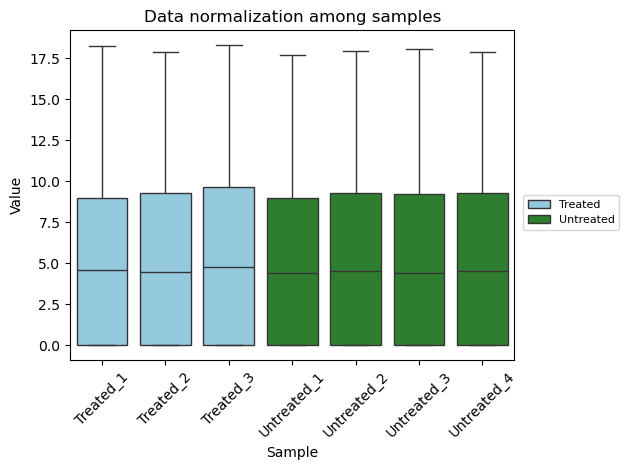

In [5]:
colors = ['skyblue', 'forestgreen']
sns.boxplot(
    data=count_log2_melt,
    x='Sample',
    y='Value',
    hue='Cond',
    palette=colors
)
plt.legend(
    bbox_to_anchor=(1.02, 0.5),   # Position outside the axe
    loc='upper left',           # Legend location/position
    borderaxespad=0,
    fontsize = 8,
    title_fontsize=10,
    labelcolor = "black"
)
plt.title('Data normalization among samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

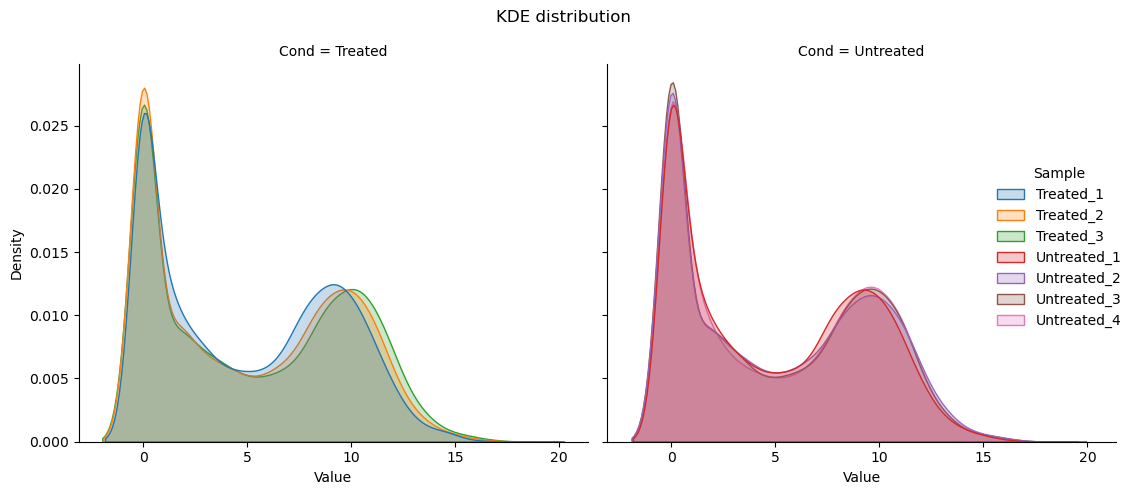

In [6]:
graph = sns.displot(
    data=count_log2_melt,
    x='Value',
    hue='Sample',
    col='Cond',
    kind='kde',
    fill=True,
    alpha=0.25
)
graph.figure.suptitle('KDE distribution')
plt.tight_layout()
plt.show()

In [7]:
expression = count_log2.T
pca = PCA(n_components=2)
principal_components = pca.fit_transform(expression); print(principal_components)
pc1, pc2 = pca.explained_variance_ratio_ * 100
conditions = count_log2.columns.str.replace('_.$', '', regex=True)
cols = [f'PC1 ({pc1:.2f}%)', f'PC2 ({pc2:.2f}%)']
pca_df = pd.DataFrame(data=principal_components, columns=cols, index=expression.index); display(pca_df)
pca_df['Condition'] = conditions; display(pca_df)

[[ 64.80299227 -34.78879453]
 [-23.73331094 -31.00408354]
 [-51.66931806 -38.58804819]
 [ 52.50886823  15.25889032]
 [-15.34814511  31.63775512]
 [-19.0550792   31.11925236]
 [ -7.50600719  26.36502847]]


,PC1 (32.20%),PC2 (19.47%)
Treated_1,64.802992,-34.788795
Treated_2,-23.733311,-31.004084
Treated_3,-51.669318,-38.588048
Untreated_1,52.508868,15.258890
Untreated_2,-15.348145,31.637755
Untreated_3,-19.055079,31.119252
Untreated_4,-7.506007,26.365028


,PC1 (32.20%),PC2 (19.47%),Condition
Treated_1,64.802992,-34.788795,Treated
Treated_2,-23.733311,-31.004084,Treated
Treated_3,-51.669318,-38.588048,Treated
Untreated_1,52.508868,15.258890,Untreated
Untreated_2,-15.348145,31.637755,Untreated
Untreated_3,-19.055079,31.119252,Untreated
Untreated_4,-7.506007,26.365028,Untreated


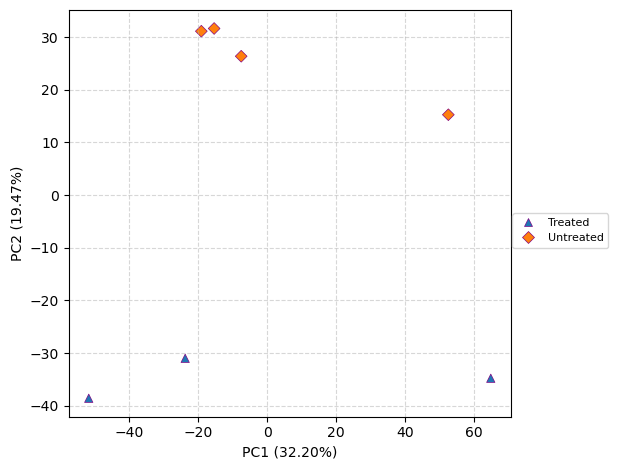

In [8]:
markers = ['^', 'D']
sns.scatterplot(
    data=pca_df,
    x=cols[0],
    y=cols[1],
    hue="Condition",           # Color according to species
    style="Condition",             # Shape according to sex
    edgecolor="purple",        # Constante edge color
    markers=markers
)
plt.legend(
    bbox_to_anchor=(1.22, 0.5),   # Position outside the axe
    loc='upper right',           # Legend location/position
    borderaxespad=0,
    fontsize = 8,
    title_fontsize=10,
    labelcolor = "black"
)
plt.tight_layout()
plt.grid(True, alpha=0.5, linestyle='--')
plt.show()

## Filtrado de los datos

In [9]:
def cmp(df: pd.DataFrame):
    return (df / df.sum()) * 1000000

In [10]:
count_filter = count[(cmp(count) >= 5).sum(axis=1) >= 3]; display(count_filter.head())
print(count_filter.shape)

,Treated_1,Treated_2,Treated_3,Untreated_1,Untreated_2,Untreated_3,Untreated_4
FBgn0002121,3998,3175,3663,4612,4611,3287,4366
FBgn0051973,312,290,390,325,394,321,309
FBgn0067779,814,573,685,869,690,640,758
FBgn0266322,275,284,275,227,239,229,302
FBgn0031213,1157,892,1065,894,1069,977,1129


(7700, 7)


## DESeq2 en Python

In [11]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

See code available at moodle

## Analysis of thos results

In [12]:
pydeseq2_res = pd.read_csv('data/exp_dif.csv', sep=',', index_col=0)
cond = [
    (pydeseq2_res["padj"] <= 0.01) & (pydeseq2_res["log2FoldChange"] >= 2),
    (pydeseq2_res["padj"] <= 0.01) & (pydeseq2_res["log2FoldChange"] <= -2)
]

opc = ["UP", "DOWN"]

pydeseq2_res["Expression"] = np.select(cond, opc, default="Non-DE")

In [19]:
# -log10(padj)
pydeseq2_res["log10Neg"] = -np.log10(pydeseq2_res["padj"].clip(lower=1e-300))
display(pydeseq2_res.head())

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Expression,log10Neg
ID=FBgn0000003,581.553898,0.506048,0.292623,1.729353,0.083746,0.395787,Non-DE,0.402538
ID=FBgn0000008,198.640785,-0.225887,0.191148,-1.181740,0.237309,0.680157,Non-DE,0.167391
ID=FBgn0000017,8129.732194,-0.257709,0.241625,-1.066568,0.286167,0.729087,Non-DE,0.137220
ID=FBgn0000018,506.839036,-0.049218,0.138921,-0.354284,0.723126,0.945488,Non-DE,0.024344
ID=FBgn0000032,1198.792684,-0.070505,0.153523,-0.459245,0.646058,0.921147,Non-DE,0.035671


## Plotting

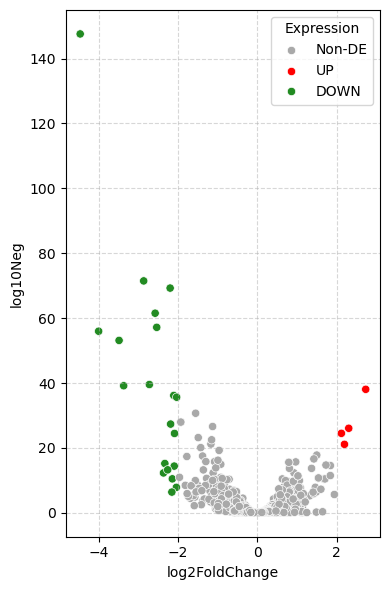

In [14]:
plt.figure(figsize=(4,6))
colors = {
    "UP" : "red",
    "DOWN" : "forestgreen",
    "Non-DE" : "darkgray"
}
sns.scatterplot(
    data=pydeseq2_res,
    x="log2FoldChange",
    y="log10Neg",
    hue="Expression",
    palette=colors
)
plt.tight_layout()
plt.grid(True, alpha=0.5, linestyle="--")
plt.show()

Obtener los conteos normalizados:

1. Con `deseq2_norm(count_filter)`
2. A partir del objeto de `dds`:
```python
pd.DataFrame(
    dds.layer["normed_counts"].T,
    index=dds.var_names,
    columns=dds.obs_names
)
```

In [15]:
norm_counts = pd.read_csv("data/ConteosNormaliz.csv", index_col=0)#; display(norm_counts)
genes = pydeseq2_res[pydeseq2_res["Expression"] != "Non-DE"].index#; print(genes)
htmp_data  = np.log1p(norm_counts.loc[genes])#; display(htmp_data)

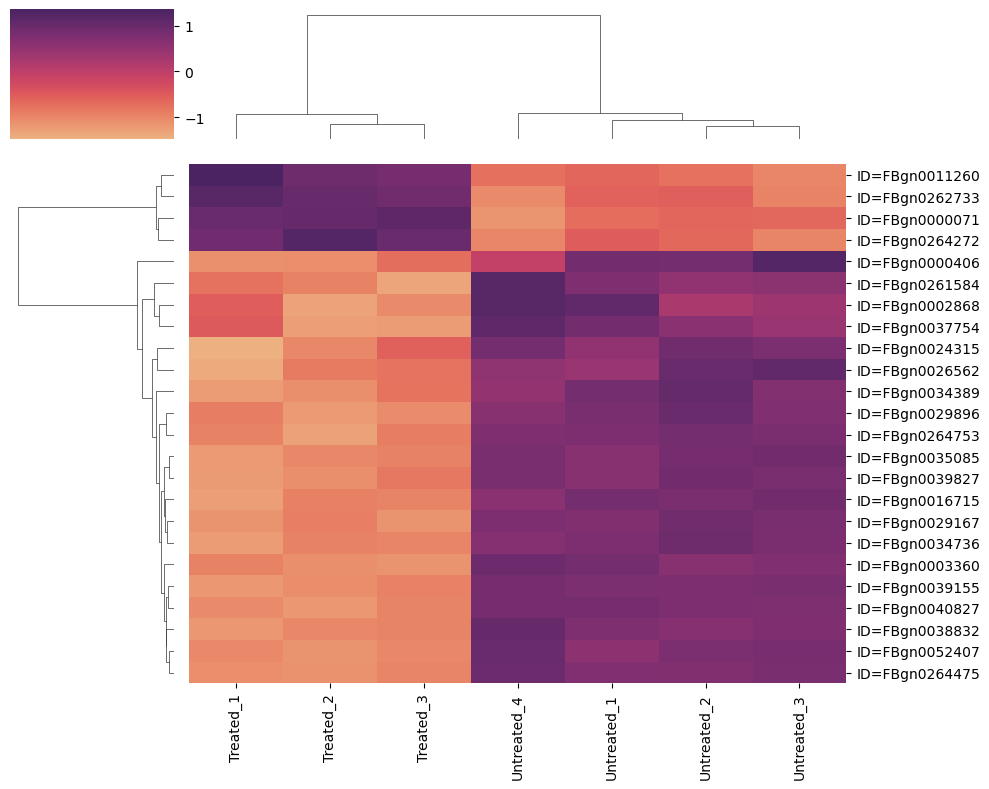

In [16]:
sns.clustermap(
    data=htmp_data,
    z_score=0,
    cmap="flare",
    col_cluster=True,
    row_cluster=True,
    figsize=(10,8)
)
plt.tight_layout()
plt.show()